# Initial Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

In [3]:
def evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=False):
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1-score:", round(f1,4))
    print("ROC-AUC:", round(auc,4))

    if plot_conf_matx:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

# Train RF model

In [4]:
# Load and prepare data
df = pd.read_csv("final_cleaned_data.csv")

df = df.drop(columns=["index", "id"])

binary_cols = [col for col in df.columns if (df[col].nunique() == 2 or df[col].nunique() == 1)]
df[binary_cols] = df[binary_cols].astype('category')

print(df.shape)

(1650, 70)


In [5]:
features = df.drop("delivery_method", axis=1)
labels = df["delivery_method"]   # 809 natural, 841 cesarean

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Initial RF training
rfmodel = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rfmodel.fit(X_train, y_train)
y_pred = rfmodel.predict(X_test)


# Extract Feature Importances
importances = rfmodel.feature_importances_
feature_names = features.columns

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

Accuracy: 0.8242
Precision: 0.7594
Recall: 0.9583
F1-score: 0.8474
ROC-AUC: 0.8634


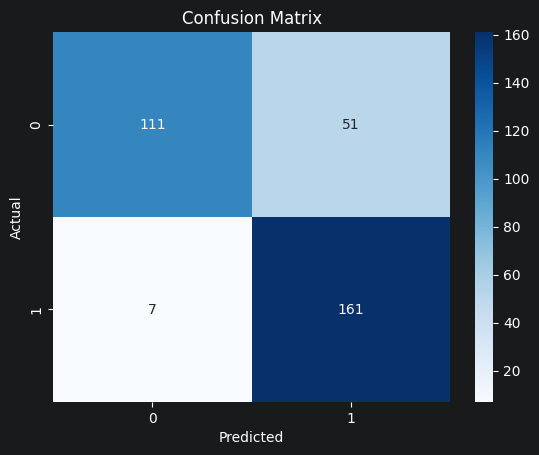

In [6]:
# Final RF Training to get the best model
k = 45
topk_features = importance_df.head(k)["feature"].tolist()
X = X_train[topk_features]
y = y_train

best_rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

best_rf.fit(X, y)

y_pred = best_rf.predict(X_test[topk_features])

y_prob = best_rf.predict_proba(X_test[topk_features])[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

# Prediction for New Record

In [7]:
# Load and prepare new record
df_test = pd.read_csv("sample_record.csv")

df_test = df_test.drop(columns=["index", "id"])

binary_cols = [col for col in df_test.columns if (df_test[col].nunique() == 2 or df_test[col].nunique() == 1)]
df_test[binary_cols] = df_test[binary_cols].astype('category')

print(df_test.shape)  # it does not contain any label "delivery_method"

(1, 69)


In [8]:
df_test.head()

,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,num_maternal_deaths,cnt_abortions,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
y_pred = best_rf.predict(df_test[topk_features])
print("Natural" if y_pred == 0 else "Cesarean")

Cesarean
